In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('iris.csv')#loading dataset 

In [3]:
df.head()#taking overview of actual dataset

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.shape

(150, 6)

In [5]:
df.info() #according to info function, there is no missing values in dataset

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [6]:
df = df.iloc[:, 1:] #preprocessing-removing extra columns

In [7]:
df.head()# preprocessed dataset

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [9]:
import matplotlib.pyplot as plt #Importing Modules for visualization
import seaborn as sns

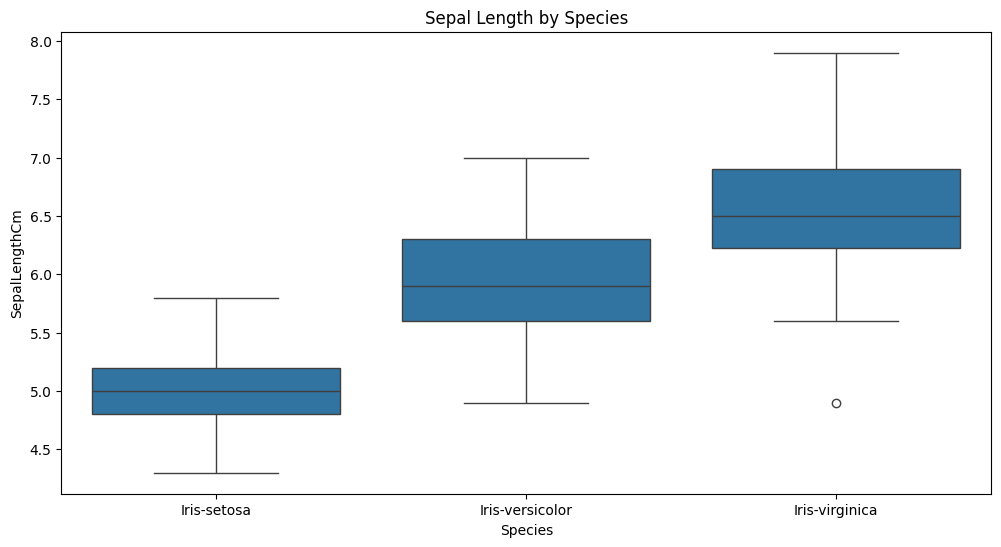

In [10]:
plt.figure(figsize=(12, 6)) #EDA-Exploratory Data Analysis- for better interpretation of data
sns.boxplot(x='Species', y='SepalLengthCm', data=df)
plt.title('Sepal Length by Species')
plt.show()

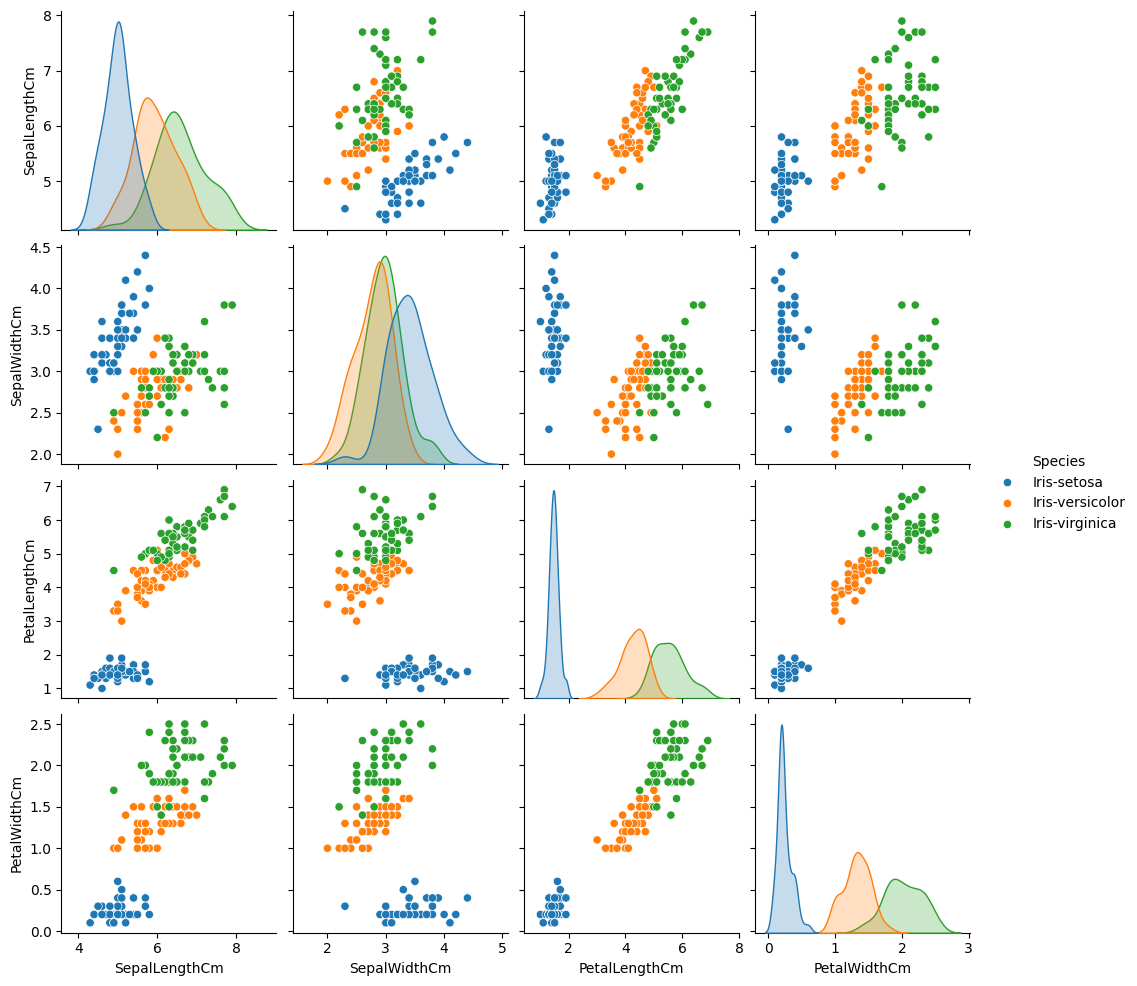

In [11]:
sns.pairplot(df, hue='Species')#EDA-Exploratory Data Analysis-for better interpretation of data
plt.show()

In [12]:
X = df.iloc[:, :-1] #extracting input columns
y = df.iloc[:, -1]#extracting output columns

In [13]:
X.shape #shape of input-2D tensor- Combination of 4D vectors

(150, 4)

In [14]:
y.shape #shape of output-1D tensor-Combination of scalars

(150,)

In [15]:
from sklearn.model_selection import train_test_split # using it so that we can later on during evaluation of model 

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)#80% for training and 20% for testing

In [16]:
from sklearn.preprocessing import LabelEncoder # labelling Y column which is my output column which is in characters but scikit-learn work numbers

le = LabelEncoder() 

# Fit on training labels and transform both train & test
y_train_encoded = le.fit_transform(y_train) # mapped different type of flower to number
y_test_encoded = le.transform(y_test)

# Check the mapping
print("Class mapping:")
for i, class_name in enumerate(le.classes_):
    print(f"{class_name} → {i}")


Class mapping:
Iris-setosa → 0
Iris-versicolor → 1
Iris-virginica → 2


In [17]:
X_train

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
79,5.7,2.6,3.5,1.0
48,5.3,3.7,1.5,0.2
52,6.9,3.1,4.9,1.5
122,7.7,2.8,6.7,2.0
70,5.9,3.2,4.8,1.8
...,...,...,...,...
77,6.7,3.0,5.0,1.7
17,5.1,3.5,1.4,0.3
0,5.1,3.5,1.4,0.2
74,6.4,2.9,4.3,1.3


In [18]:
X_test

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
126,6.2,2.8,4.8,1.8
109,7.2,3.6,6.1,2.5
28,5.2,3.4,1.4,0.2
76,6.8,2.8,4.8,1.4
7,5.0,3.4,1.5,0.2
57,4.9,2.4,3.3,1.0
125,7.2,3.2,6.0,1.8
90,5.5,2.6,4.4,1.2
29,4.7,3.2,1.6,0.2
20,5.4,3.4,1.7,0.2


In [19]:
y_train.head()

79     Iris-versicolor
48         Iris-setosa
52     Iris-versicolor
122     Iris-virginica
70     Iris-versicolor
Name: Species, dtype: str

In [20]:
y_train_encoded #encoded 

array([1, 0, 1, 2, 1, 2, 2, 0, 0, 2, 1, 0, 0, 2, 2, 0, 1, 2, 2, 0, 1, 2,
       0, 0, 0, 2, 2, 2, 2, 2, 0, 2, 2, 2, 1, 0, 1, 0, 2, 1, 1, 0, 0, 0,
       1, 1, 2, 1, 0, 0, 2, 0, 1, 1, 0, 0, 0, 2, 1, 0, 1, 2, 0, 2, 0, 1,
       1, 1, 1, 2, 0, 0, 1, 2, 0, 2, 1, 1, 2, 1, 1, 2, 2, 2, 2, 0, 2, 1,
       1, 0, 1, 0, 0, 2, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 1, 2, 0, 0,
       1, 2, 0, 1, 0, 1, 0, 0, 1, 0])

In [21]:
y_test

126     Iris-virginica
109     Iris-virginica
28         Iris-setosa
76     Iris-versicolor
7          Iris-setosa
57     Iris-versicolor
125     Iris-virginica
90     Iris-versicolor
29         Iris-setosa
20         Iris-setosa
82     Iris-versicolor
123     Iris-virginica
3          Iris-setosa
13         Iris-setosa
128     Iris-virginica
56     Iris-versicolor
103     Iris-virginica
84     Iris-versicolor
6          Iris-setosa
67     Iris-versicolor
51     Iris-versicolor
92     Iris-versicolor
107     Iris-virginica
8          Iris-setosa
24         Iris-setosa
113     Iris-virginica
137     Iris-virginica
118     Iris-virginica
93     Iris-versicolor
96     Iris-versicolor
Name: Species, dtype: str

In [22]:
y_test_encoded

array([2, 2, 0, 1, 0, 1, 2, 1, 0, 0, 1, 2, 0, 0, 2, 1, 2, 1, 0, 1, 1, 1,
       2, 0, 0, 2, 2, 2, 1, 1])

In [23]:
from sklearn.preprocessing import StandardScaler # fitting values in range of -1 to 1
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.fit_transform(X_test)

In [24]:
X_train

array([[-0.20176351, -1.06047306, -0.13194419, -0.26483219],
       [-0.70097221,  1.38250152, -1.26694794, -1.30679489],
       [ 1.29586258,  0.04996993,  0.66255844,  0.3863945 ],
       [ 2.29427997, -0.61629586,  1.68406183,  1.0376212 ],
       [ 0.04784083,  0.27205853,  0.60580826,  0.77713052],
       [ 0.29744518, -1.06047306,  1.05980976,  0.25614917],
       [ 1.04625823,  0.49414713,  1.11655995,  1.68884789],
       [-0.07696134,  2.04876732, -1.43719851, -1.30679489],
       [-0.45136786,  2.49294451, -1.32369813, -1.30679489],
       [-1.20018091, -1.28256165,  0.43555769,  0.64688518],
       [ 1.04625823,  0.04996993,  0.54905807,  0.3863945 ],
       [-1.07537873,  0.93832433, -1.21019776, -0.78581354],
       [-0.57617004,  1.82667872, -1.38044832, -1.04630422],
       [ 0.54704953,  0.71623573,  1.05980976,  1.55860255],
       [-0.32656569, -0.61629586,  0.66255844,  1.0376212 ],
       [-1.20018091,  0.04996993, -1.26694794, -1.43704023],
       [-0.32656569, -0.

In [25]:
X_test

array([[ 0.47176848, -0.47866162,  0.53824998,  0.84822809],
       [ 1.56890449,  1.91464647,  1.28528732,  1.80590496],
       [-0.62536752,  1.31631945, -1.41553999, -1.34074762],
       [ 1.13005009, -0.47866162,  0.53824998,  0.30098416],
       [-0.84479473,  1.31631945, -1.35807558, -1.34074762],
       [-0.95450833, -1.67531567, -0.32371618, -0.24625977],
       [ 1.56890449,  0.71799243,  1.22782291,  0.84822809],
       [-0.29622672, -1.07698864,  0.30839234,  0.0273622 ],
       [-1.17393553,  0.71799243, -1.30061116, -1.34074762],
       [-0.40594032,  1.31631945, -1.24314675, -1.34074762],
       [ 0.03291408, -0.77782513,  0.02107028,  0.0273622 ],
       [ 0.58148208, -0.77782513,  0.59571439,  0.84822809],
       [-1.28364913,  0.41882892, -1.35807558, -1.34074762],
       [-1.61278993,  0.1196654 , -1.58793322, -1.47755861],
       [ 0.69119568, -0.47866162,  0.99796527,  1.25866104],
       [ 0.58148208,  1.01715594,  0.48078557,  0.57460612],
       [ 0.58148208, -0.

In [26]:
from sklearn.tree import DecisionTreeClassifier # calling model 
model=DecisionTreeClassifier(random_state=42) # random_state is attribute to control randomness

In [28]:
model.fit(X_train,y_train_encoded) # training model

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [29]:
y_pred = model.predict(X_test) # predicted values for X_test

In [30]:
y_pred 

array([2, 2, 0, 1, 0, 1, 2, 1, 0, 0, 1, 2, 0, 0, 2, 1, 2, 1, 0, 1, 1, 1,
       2, 0, 0, 2, 2, 2, 1, 1])

In [31]:
y_test_encoded

array([2, 2, 0, 1, 0, 1, 2, 1, 0, 0, 1, 2, 0, 0, 2, 1, 2, 1, 0, 1, 1, 1,
       2, 0, 0, 2, 2, 2, 1, 1])

In [32]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print("Accuracy:\n", accuracy_score(y_test_encoded,y_pred))# Evaluation of model based on accuracy
print("Confusion Matrix:\n", confusion_matrix(y_test_encoded, y_pred))# Confusion matrix of model
print("Classification Report:\n", classification_report(y_test_encoded, y_pred, target_names=le.classes_))# Classification report of model

Accuracy:
 1.0
Confusion Matrix:
 [[ 9  0  0]
 [ 0 11  0]
 [ 0  0 10]]
Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         9
Iris-versicolor       1.00      1.00      1.00        11
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



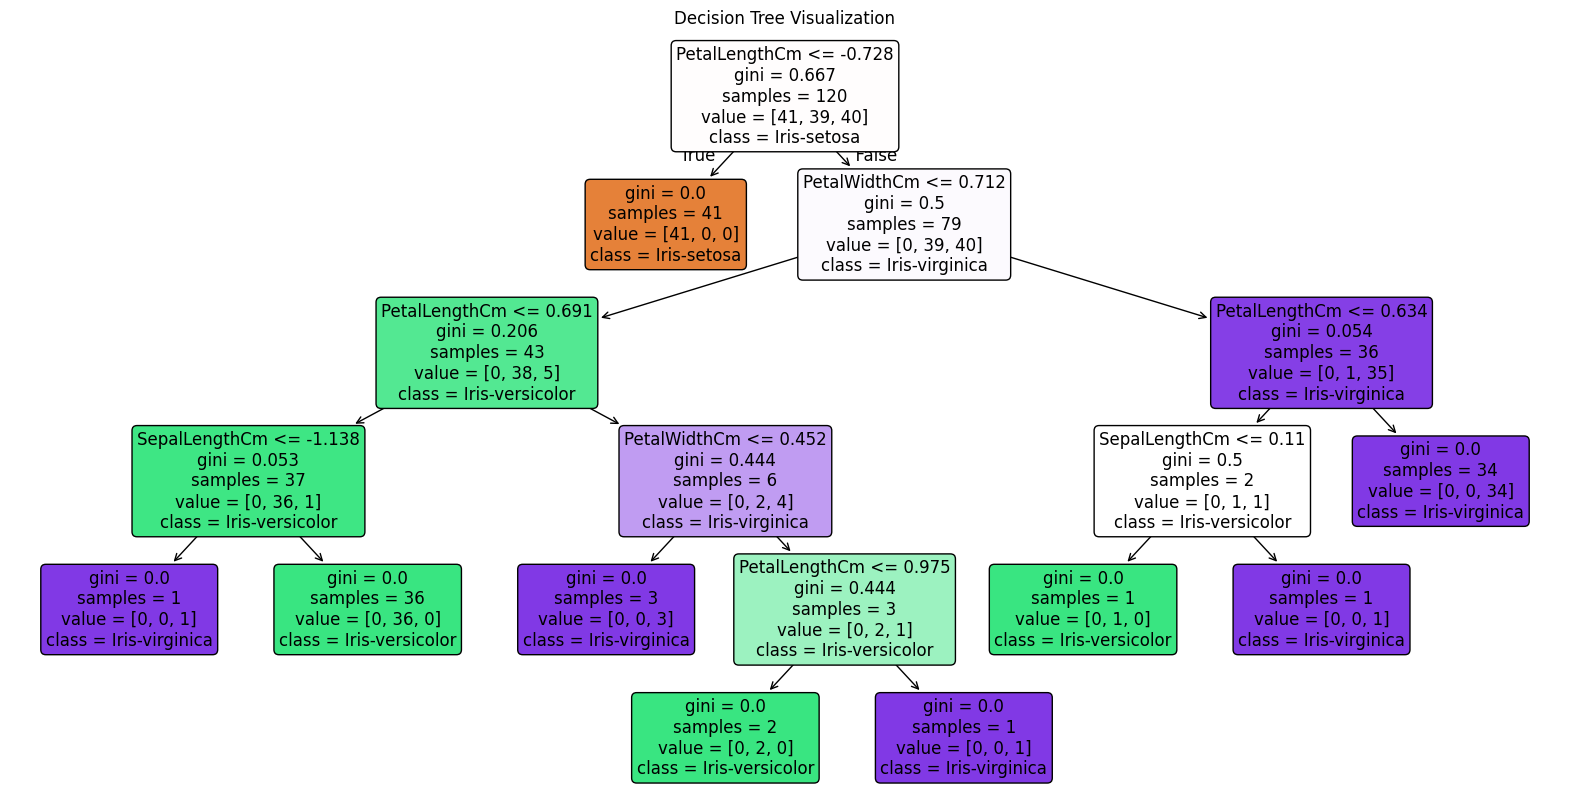

In [33]:
from sklearn.tree import plot_tree # Vizualizing decision tree using plot_tree from sklearn.plot_tree
plt.figure(figsize=(20,10))
plot_tree(
    model, 
    feature_names=X.columns,   
    class_names=le.classes_,       
    filled=True, 
    rounded=True, 
    fontsize=12
)
plt.title("Decision Tree Visualization")
plt.show()


In [36]:
#Analysis of Decision tree
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)
print("Feature Importance:\n", feature_importance)
print("Tree Depth:", model.get_depth())
print("Number of Leaves:", model.get_n_leaves())

Feature Importance:
          Feature  Importance
2  PetalLengthCm    0.587523
3   PetalWidthCm    0.375645
0  SepalLengthCm    0.036832
1   SepalWidthCm    0.000000
Tree Depth: 5
Number of Leaves: 9
